# 02 — Preprocessing pipeline

Every image passes through the same four steps before a model sees it, all
implemented in `src/data/preprocessing.py`:

| Step | Function | Purpose |
|---|---|---|
| 1. Crop | `crop_brain_region()` | Remove the black border so the 224x224 budget is spent on anatomy |
| 2. Resize | `cv2.resize(..., INTER_AREA)` | Fixed 224x224 model input |
| 3. CLAHE | `cv2.createCLAHE()` | Local contrast enhancement — makes tissue boundaries visible |
| 4. Scale | `/255`, then `x255` for TensorFlow | Match what the backbone expects |

This notebook shows each step, then covers two subtleties that are easy to get
wrong: the input range EfficientNet requires, and how the weak segmentation
labels are produced.

In [1]:
import os
import sys
import warnings
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"      # quiet TensorFlow startup logging
warnings.filterwarnings("ignore")

import cv2
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

from src.data.preprocessing import (
    crop_brain_region,
    generate_pseudo_mask,
    preprocess_image,
    segment_brain,
)
from src.utils.project import CLASS_NAMES, EFFICIENTNET_INPUT_SCALE, load_config, resolve_raw_dir

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

RAW_DIR = resolve_raw_dir(load_config("configs/config.yaml"))
SAMPLES = {cls: sorted((RAW_DIR / "Training" / cls).glob("*.jpg"))[0] for cls in CLASS_NAMES}

print("dataset root:", RAW_DIR)
for cls, path in SAMPLES.items():
    print(f"  {cls:12s} {path.name}")

dataset root: Dataset
  glioma       Tr-gl_1.jpg
  meningioma   Tr-aug-me_1.jpg
  notumor      Tr-no_1.jpg
  pituitary    Tr-pi_1.jpg


## Step 1 — Crop to the brain region

Notebook 01 measured a median background fraction of 44%, reaching 75% in the
worst case. Almost half of a typical slice is empty space.

`crop_brain_region()` thresholds the image, applies a morphological close and
open to clean up speckle, finds the largest external contour, and crops to its
bounding box with 10px of padding.

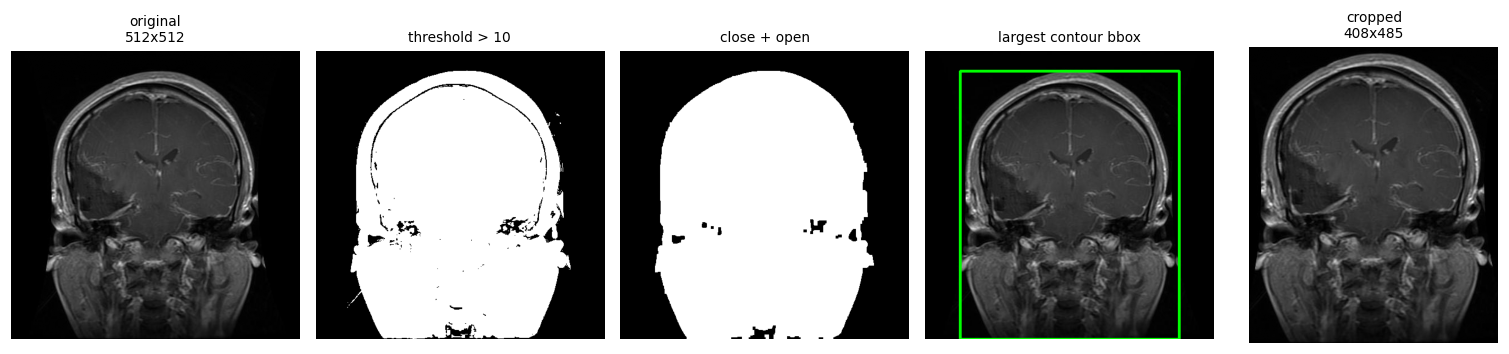

area removed: 24.5%


In [2]:
def crop_steps(gray, threshold=10):
    """Reproduce crop_brain_region's intermediates for visualisation."""
    _, thresh = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    kernel = np.ones((5, 5), np.uint8)
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel)
    contours, _ = cv2.findContours(opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    box = cv2.boundingRect(max(contours, key=cv2.contourArea)) if contours else None
    return thresh, opened, box


gray = cv2.imread(str(SAMPLES["glioma"]), cv2.IMREAD_GRAYSCALE)
thresh, cleaned, box = crop_steps(gray)
cropped = crop_brain_region(gray)

boxed = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
x, y, w, h = box
cv2.rectangle(boxed, (x, y), (x + w, y + h), (0, 255, 0), 3)

panels = [
    (gray, f"original\n{gray.shape[1]}x{gray.shape[0]}", "gray"),
    (thresh, "threshold > 10", "gray"),
    (cleaned, "close + open", "gray"),
    (boxed, "largest contour bbox", None),
    (cropped, f"cropped\n{cropped.shape[1]}x{cropped.shape[0]}", "gray"),
]

fig, axes = plt.subplots(1, 5, figsize=(14, 3.2))
for ax, (img, title, cmap) in zip(axes, panels):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"area removed: {100 * (1 - cropped.size / gray.size):.1f}%")

## Step 3 — CLAHE

Ordinary histogram equalisation stretches contrast globally, which amplifies
noise in the dark background. CLAHE (Contrast Limited Adaptive Histogram
Equalization) equalises within small tiles and clips the histogram, so it lifts
local tissue contrast without blowing up noise.

The pipeline applies it to the L channel in LAB space, leaving colour untouched.

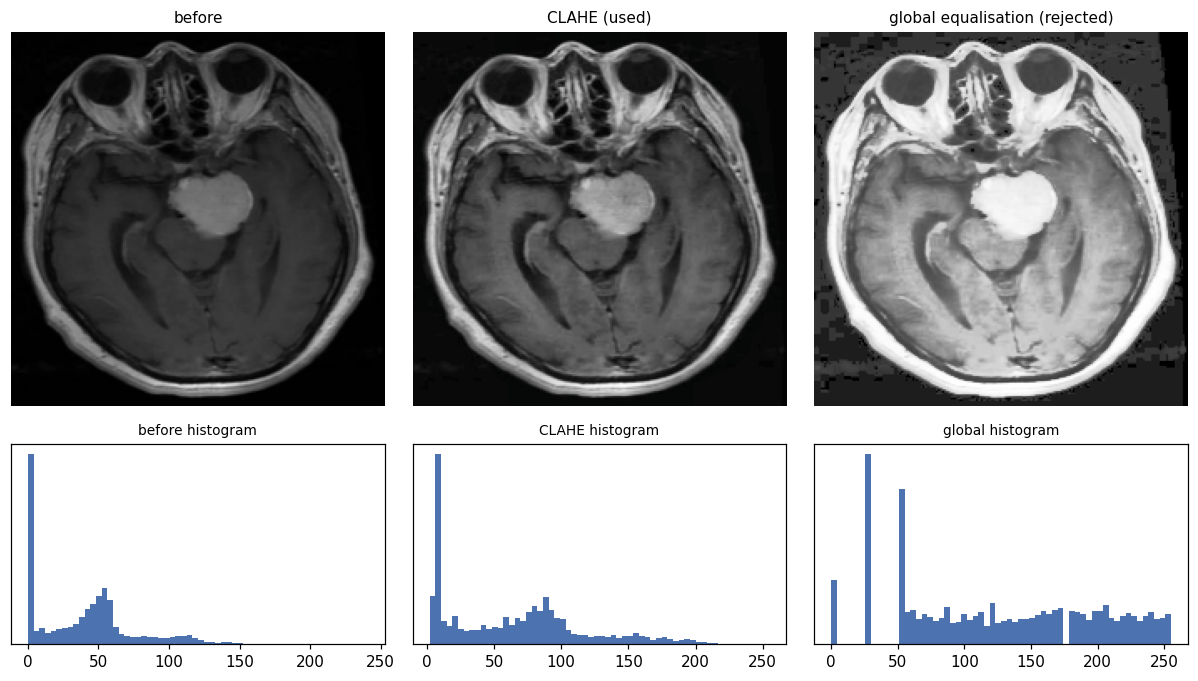

before   mean=  41.7  std= 36.6  (std = contrast)
CLAHE    mean=  65.8  std= 52.7  (std = contrast)
global   mean= 126.4  std= 73.1  (std = contrast)


In [3]:
def clahe_only(rgb, clip_limit=2.0, tile=(8, 8)):
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    lab[:, :, 0] = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile).apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)


bgr = cv2.imread(str(SAMPLES["meningioma"]))
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
rgb = cv2.resize(crop_brain_region(rgb), (224, 224), interpolation=cv2.INTER_AREA)

enhanced = clahe_only(rgb)
global_eq = cv2.cvtColor(cv2.equalizeHist(cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)),
                         cv2.COLOR_GRAY2RGB)

fig, axes = plt.subplots(2, 3, figsize=(11, 6.4),
                         gridspec_kw={"height_ratios": [2.2, 1]})
for ax, (img, title) in zip(axes[0], [(rgb, "before"), (enhanced, "CLAHE (used)"),
                                      (global_eq, "global equalisation (rejected)")]):
    ax.imshow(img)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

for ax, (img, title) in zip(axes[1], [(rgb, "before"), (enhanced, "CLAHE"),
                                      (global_eq, "global")]):
    ax.hist(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).ravel(), bins=60, color="#4C72B0")
    ax.set_title(f"{title} histogram", fontsize=9)
    ax.set_yticks([])

plt.tight_layout()
plt.show()

for name, img in [("before", rgb), ("CLAHE", enhanced), ("global", global_eq)]:
    g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    print(f"{name:8s} mean={g.mean():6.1f}  std={g.std():5.1f}  (std = contrast)")

Global equalisation produces the highest raw contrast number, but the histogram
shows why it is rejected: it stretches the huge background peak, amplifying noise
in regions that carry no information. CLAHE raises tissue contrast while leaving
the background alone.

## The full pipeline, per class

`preprocess_image()` chains all of the above and returns float32 in [0, 1].

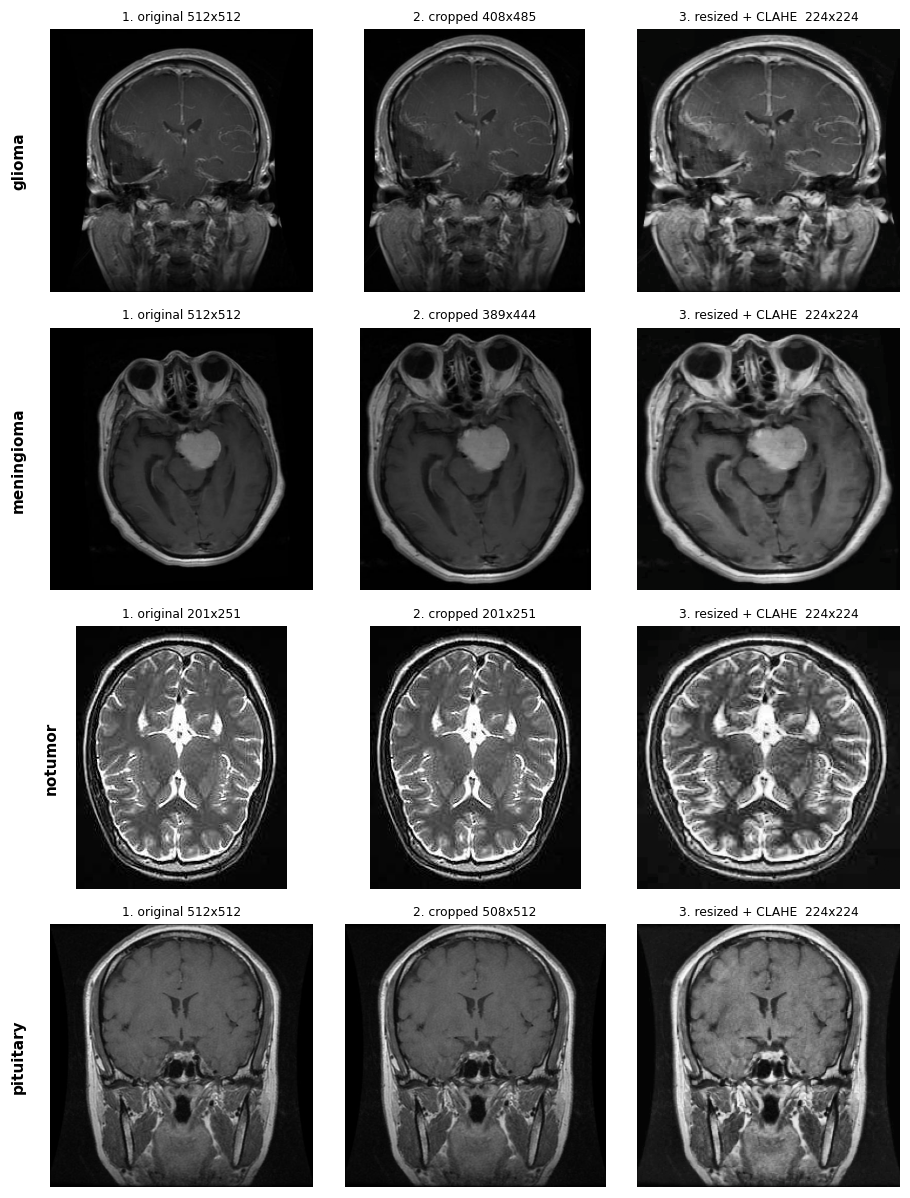

preprocess_image returns (224, 224, 3) float32 in [0.01, 0.98]


In [4]:
fig, axes = plt.subplots(len(CLASS_NAMES), 3, figsize=(8.5, 11))

for row, cls in enumerate(CLASS_NAMES):
    path = SAMPLES[cls]
    original = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    cropped = crop_brain_region(original)
    final = preprocess_image(str(path), 224)

    for col, (img, title) in enumerate([
        (original, f"1. original {original.shape[1]}x{original.shape[0]}"),
        (cropped, f"2. cropped {cropped.shape[1]}x{cropped.shape[0]}"),
        (final, "3. resized + CLAHE  224x224"),
    ]):
        axes[row, col].imshow(img)
        axes[row, col].set_title(title, fontsize=8)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(cls)
    axes[row, 0].text(-0.12, 0.5, cls, transform=axes[row, 0].transAxes,
                      rotation=90, va="center", ha="center", fontsize=10, weight="bold")

plt.tight_layout()
plt.show()

out = preprocess_image(str(SAMPLES["glioma"]), 224)
print(f"preprocess_image returns {out.shape} {out.dtype} in [{out.min():.2f}, {out.max():.2f}]")

## Step 4 — Input range: the easy mistake

`preprocess_image()` returns values in **[0, 1]**, but the two frameworks want
different things from there, and getting this wrong is silent — the model still
trains, just badly.

**TensorFlow / EfficientNet.** `keras.applications.EfficientNet*` begins with its
own `Rescaling(1/255)` and `Normalization` layers, so it expects raw pixels in
**[0, 255]**. Applying ImageNet mean/std normalisation before handing it over
normalises twice.

**PyTorch / U-Net.** `segmentation_models_pytorch` encoders have no built-in
preprocessing, so ImageNet mean/std normalisation *is* required there.

The cell below inspects the first layers of the backbone and measures what the
convolutional stem actually receives under each convention.

In [5]:
from src.models.backbone import build_efficientnet_b3

backbone = build_efficientnet_b3(img_size=224, pretrained=True)

print("First layers of EfficientNetB3:")
for layer in backbone.layers[:4]:
    print(f"  {type(layer).__name__:16s} {layer.name}")
print("\n-> the Rescaling and Normalization layers are inside the model,")
print("   which is why it wants [0, 255] input.\n")

import keras
pre_stem = keras.Model(backbone.inputs, backbone.get_layer("stem_conv_pad").input)

image01 = preprocess_image(str(SAMPLES["glioma"]), 224)
correct = pre_stem.predict(image01[None] * EFFICIENTNET_INPUT_SCALE, verbose=0)

mean = np.array([0.485, 0.456, 0.406], np.float32)
std = np.array([0.229, 0.224, 0.225], np.float32)
double_normalized = pre_stem.predict(((image01 - mean) / std)[None], verbose=0)

print(f"{'convention':38s} {'stem mean':>10s} {'stem std':>9s}")
print(f"{'x * 255  (correct)':38s} {correct.mean():10.4f} {correct.std():9.4f}")
print(f"{'(x - imagenet_mean) / std  (wrong)':38s} "
      f"{double_normalized.mean():10.4f} {double_normalized.std():9.4f}")
print(f"\nsignal ratio: {correct.std() / double_normalized.std():.0f}x")

Loaded ImageNet weights by layer name (Keras 3.11.3 index-loader workaround)
First layers of EfficientNetB3:
  InputLayer       input_layer_1
  Rescaling        rescaling_2
  Normalization    normalization_1
  ZeroPadding2D    stem_conv_pad

-> the Rescaling and Normalization layers are inside the model,
   which is why it wants [0, 255] input.



convention                              stem mean  stem std
x * 255  (correct)                         0.2698    0.2002
(x - imagenet_mean) / std  (wrong)        -0.0031    0.0035

signal ratio: 57x


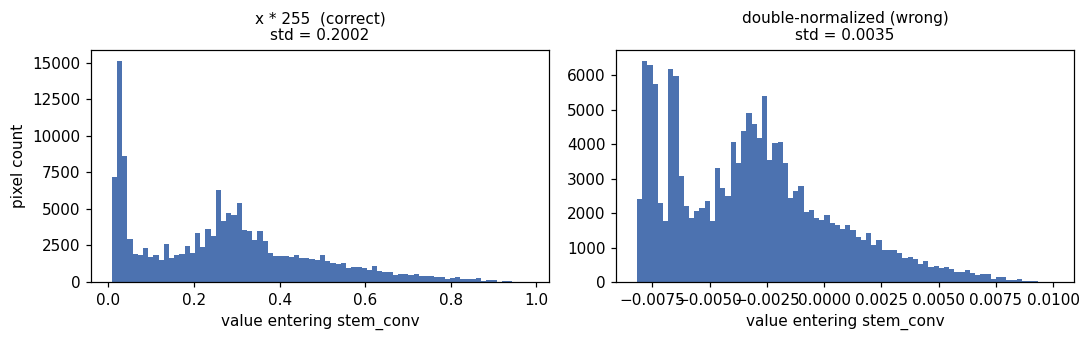

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, (tensor, title) in zip(axes, [(correct, "x * 255  (correct)"),
                                      (double_normalized, "double-normalized (wrong)")]):
    ax.hist(tensor.ravel(), bins=80, color="#4C72B0")
    ax.set_title(f"{title}\nstd = {tensor.std():.4f}", fontsize=10)
    ax.set_xlabel("value entering stem_conv")
axes[0].set_ylabel("pixel count")
plt.tight_layout()
plt.show()

The right-hand histogram is collapsed almost to a single spike. Under the wrong
convention the convolutional stem receives a nearly constant input, so the frozen
warmup phase has almost no gradient to learn from and the pretrained features are
wasted.

Both conventions still *train* — which is what makes this bug easy to miss. It
shows up only as underperformance.

## Weak segmentation labels

The dataset ships **no expert tumour masks**. `generate_pseudo_mask()` approximates
one from intensity, exploiting the fact that an enhancing tumour is usually
hyperintense on T1-contrast imaging:

1. Segment the head and erode inward — the skull and scalp are bright and would
   otherwise dominate any "find the brightest region" search.
2. Threshold at a high percentile of the intensity distribution *inside* the brain.
3. Reject candidates that hug the eroded edge (surviving skull), that are
   elongated rather than blob-shaped, or that are not a genuine intensity outlier.
4. Keep the best-scoring blob, or return an empty mask if nothing qualifies.

`notumor` scans are given an empty mask directly from their folder label rather
than being run through the heuristic.

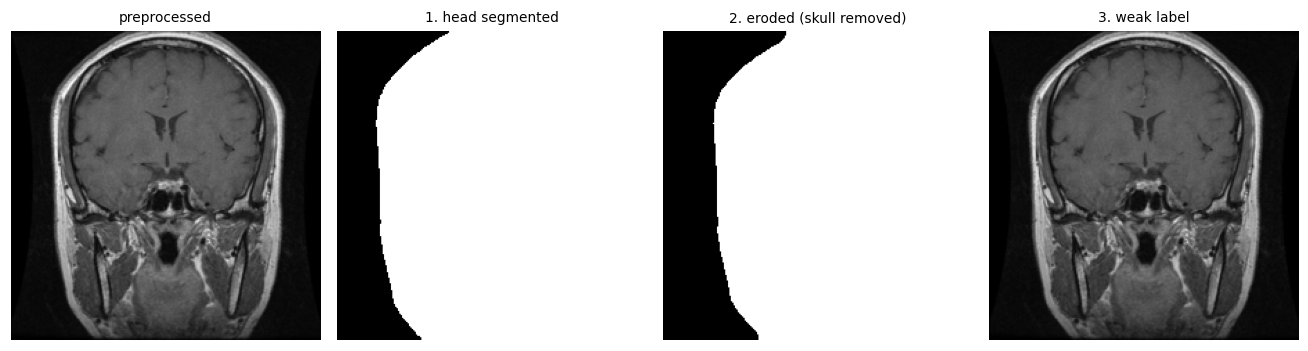

In [7]:
def overlay(gray, mask):
    rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    if mask.any():
        red = np.zeros_like(rgb)
        red[mask > 0] = (255, 0, 0)
        rgb = cv2.addWeighted(rgb, 0.75, red, 0.25, 0)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(rgb, contours, -1, (255, 255, 0), 1)
    return rgb


path = SAMPLES["pituitary"]
gray = cv2.resize(crop_brain_region(cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)),
                  (224, 224), interpolation=cv2.INTER_AREA)
brain = segment_brain(gray)
interior = cv2.erode(brain, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (17, 17)))
mask = generate_pseudo_mask(str(path), 224)

fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
for ax, (img, title, cmap) in zip(axes, [
    (gray, "preprocessed", "gray"),
    (brain, "1. head segmented", "gray"),
    (interior, "2. eroded (skull removed)", "gray"),
    (overlay(gray, mask), "3. weak label", None),
]):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

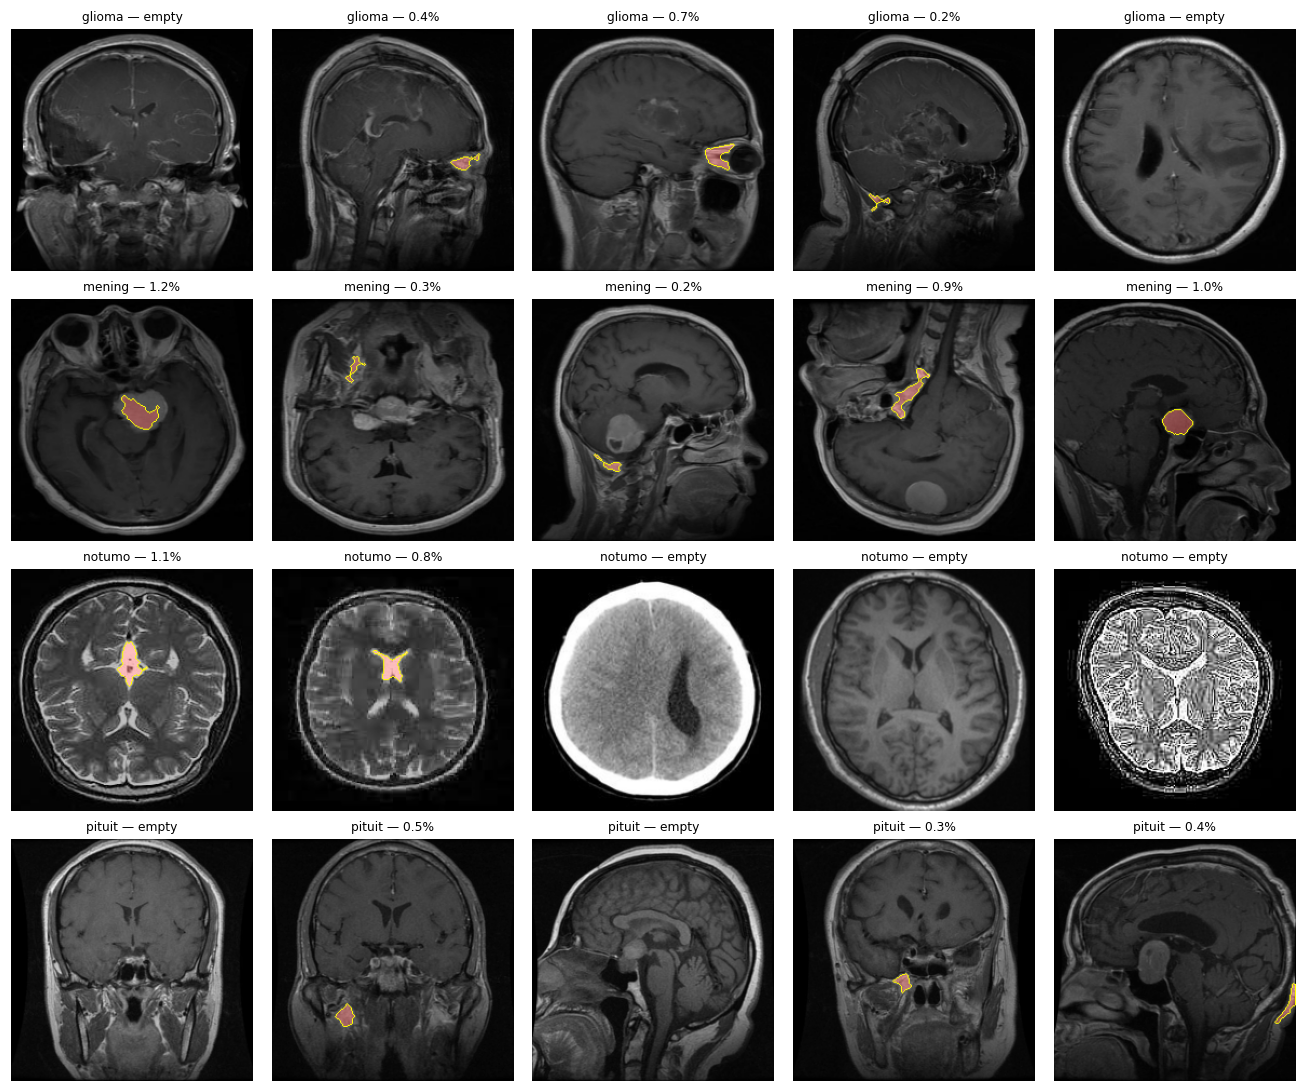

In [8]:
rng = np.random.default_rng(0)
fig, axes = plt.subplots(len(CLASS_NAMES), 5, figsize=(12, 10))

for row, cls in enumerate(CLASS_NAMES):
    paths = sorted((RAW_DIR / "Training" / cls).glob("*.jpg"))[:5]
    for col, path in enumerate(paths):
        g = cv2.resize(crop_brain_region(cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)),
                       (224, 224), interpolation=cv2.INTER_AREA)
        m = generate_pseudo_mask(str(path), 224)
        axes[row, col].imshow(overlay(g, m))
        area = 100 * (m > 0).mean()
        axes[row, col].set_title(f"{cls[:6]} — {'empty' if area == 0 else f'{area:.1f}%'}",
                                 fontsize=8)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

### Honest assessment of these labels

Measured over 40 images per class, the heuristic fires on 73% of tumour scans and
42% of `notumor` scans, and covers about 0.6% of the brain area when it does. The
previous implementation kept the largest bright component, which on a brain MRI is
the brain itself — it fired on 100% of every class at roughly 70% of brain area,
carrying no tumour information at all.

So this version is a large improvement, but look at the grid above rather than the
numbers: **roughly a third of the masks land on the actual lesion.** The rest catch
eye globes, skull-base structures or ventricles. Glioma is the weakest case.

This ceiling is not a tuning problem. Notebook 01 showed the intensity
distributions of tumour and healthy scans overlap heavily, and the blob z-score
distributions overlap almost entirely, so no intensity threshold separates them
cleanly.

**Consequences to carry into the write-up:**

- Segmentation Dice measures agreement with this heuristic, not tumour
  localisation accuracy. Report it as such.
- `src/evaluation/evaluate_all.py` averages Dice only over images that carry a
  reference lesion, because an empty prediction against an empty target scores
  1.0 and would inflate the mean.
- For a segmentation number worth quoting, train against expert annotations. The
  figshare collection (https://doi.org/10.6084/m9.figshare.1512427.v5, CC BY 4.0)
  covers these same three tumour types with manually traced borders.

Detection and classification are unaffected by any of this — they never use masks.

## Summary

| Stage | Input | Output |
|---|---|---|
| `crop_brain_region` | native grayscale/RGB | brain bounding box, ~40% of area removed |
| `cv2.resize` | cropped | 224x224 |
| CLAHE on LAB L-channel | 224x224 | locally contrast-enhanced |
| `preprocess_image` | file path | float32 [0, 1] |
| TensorFlow input | [0, 1] | **x255 -> [0, 255]** |
| PyTorch input | [0, 1] | ImageNet mean/std normalised |

Training reads pre-processed JPEGs from `data/processed` via
`tf_load_preprocessed`, which only decodes and resizes — re-running
`preprocess_image` on an already-processed file would apply CLAHE twice.